Multiple Linear Regression

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('homerates.csv')

In [4]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [5]:
m = df['bedrooms'].mean()
df['bedrooms'] = df['bedrooms'].fillna(m)

In [6]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.2,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


<Figure size 500x400 with 0 Axes>

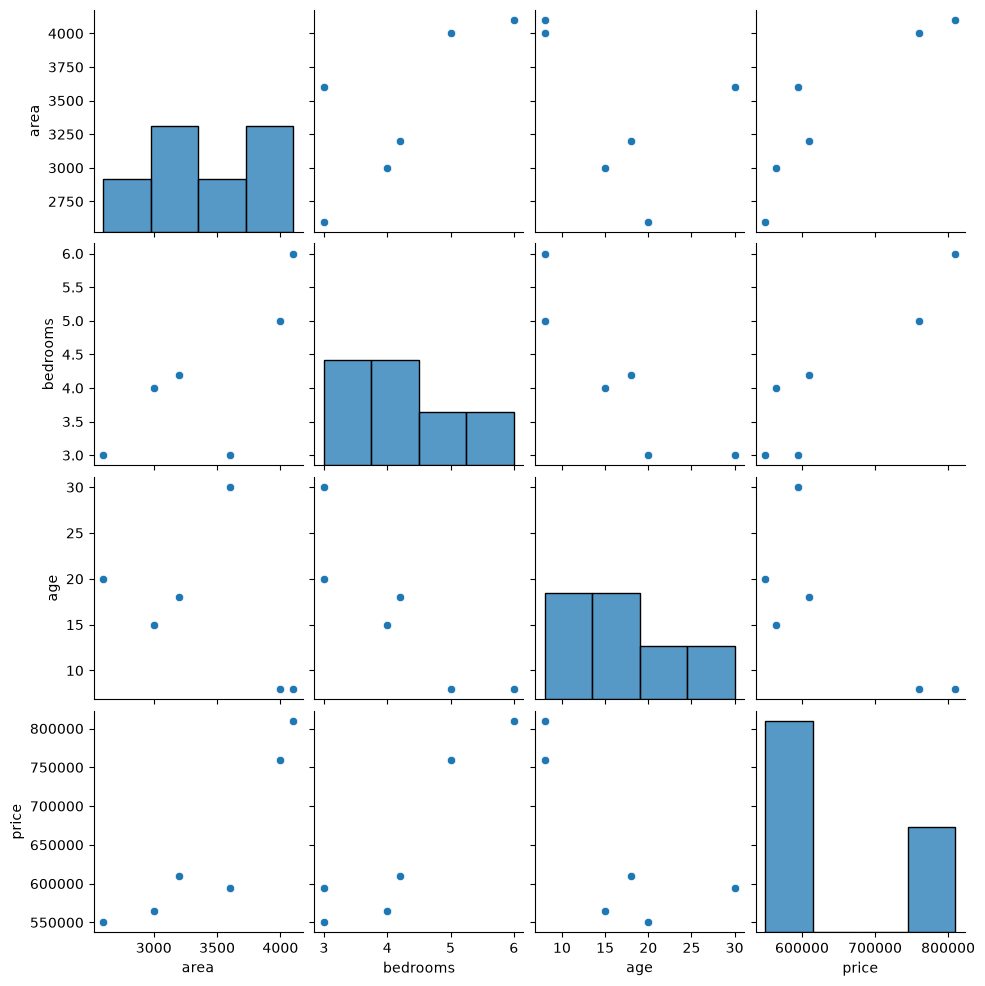

In [8]:
plt.figure(figsize=(5,4))
sns.pairplot(df)

In [9]:
df.corr()

,area,bedrooms,age,price
area,1.000000,0.740910,-0.445300,0.901476
bedrooms,0.740910,1.000000,-0.873162,0.910005
age,-0.445300,-0.873162,1.000000,-0.734167
price,0.901476,0.910005,-0.734167,1.000000


In [10]:
x = df.drop(['price'], axis = 'columns')
y = df.price

In [11]:
x

,area,bedrooms,age
0,2600,3.0,20
1,3000,4.0,15
2,3200,4.2,18
3,3600,3.0,30
4,4000,5.0,8
5,4100,6.0,8


In [13]:
x

,area,bedrooms,age
0,2600,3.0,20
1,3000,4.0,15
2,3200,4.2,18
3,3600,3.0,30
4,4000,5.0,8
5,4100,6.0,8


In [14]:
y

0    550000
1    565000
2    610000
3    595000
4    760000
5    810000
Name: price, dtype: int64

In [16]:
model = LinearRegression()
model.fit(x.values,y.values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 116.67,18756.29,-3675.75]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.316e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[1314.69, 16.67, 0.75]"


In [18]:
model.score(x.values,y.values)

0.9540926625396438

In [19]:
model.predict([[2000,3.0,20]])

array([447678.85927337])

In [21]:
model.predict([[3000,4.0,15]])

array([601483.40843428])

In [22]:
model.coef_

array([  116.66950551, 18756.28806982, -3675.75111708])

In [23]:
model.intercept_

np.float64(231586.00639409182)

In [ ]:
print((116.66950551*3000+18756.28806982*4.0+(-3675.75111708*15))+231586.00639409182)

601483.4084471718


# TASK

In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from word2number import w2n


In [87]:
df = pd.read_csv('hiring.csv')

In [88]:
df

,experience,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [89]:
df['experience'] = df['experience'].fillna('zero')
df

,experience,test_score,interview_score,salary
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [90]:
def convert_experience(x):
    if pd.isna(x):
        return x
    elif isinstance(x, str):
        return w2n.word_to_num(x)
    return x

        

In [94]:
df['experience']  = df['experience'].apply(convert_experience)

In [95]:
df

,experience,test_score,interview_score,salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


In [96]:
df

,experience,test_score,interview_score,salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


In [97]:
m2 = round(df['test_score'].mean(),2)
m2

np.float64(7.86)

In [98]:
df['test_score'] = df['test_score'].fillna(m2)

In [99]:
df

,experience,test_score,interview_score,salary
0,0,8.00,9,50000
1,0,8.00,6,45000
2,5,6.00,7,60000
3,2,10.00,10,65000
4,7,9.00,6,70000
5,3,7.00,10,62000
6,10,7.86,7,72000
7,11,7.00,8,80000


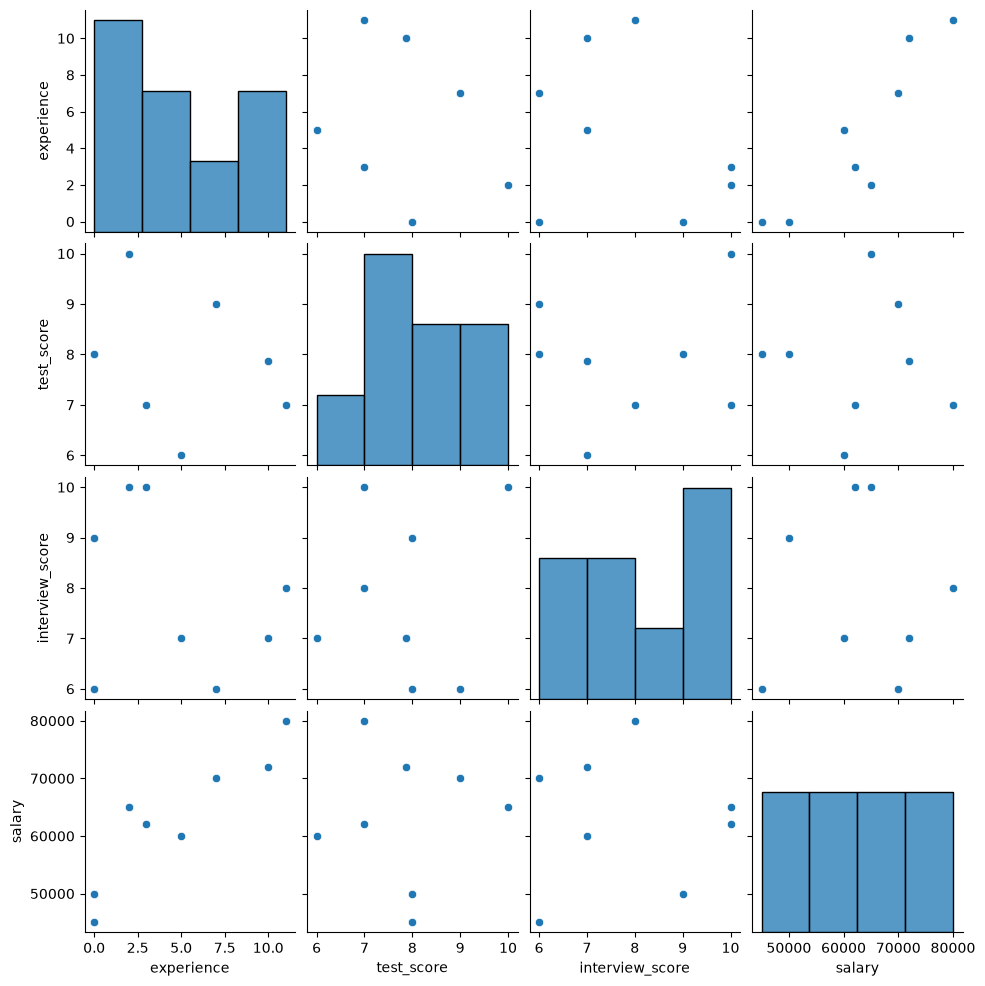

In [100]:
sns.pairplot(data = df)

In [101]:
df.corr()

,experience,test_score,interview_score,salary
experience,1.000000,-0.241493,-0.290480,0.908017
test_score,-0.241493,1.000000,0.139536,-0.002593
interview_score,-0.290480,0.139536,1.000000,0.037820
salary,0.908017,-0.002593,0.037820,1.000000


In [102]:
x = df.drop(['salary'], axis = 'columns')
y = df.salary

In [103]:
x

,experience,test_score,interview_score
0,0,8.00,9
1,0,8.00,6
2,5,6.00,7
3,2,10.00,10
4,7,9.00,6
5,3,7.00,10
6,10,7.86,7
7,11,7.00,8


In [104]:
y

0    50000
1    45000
2    60000
3    65000
4    70000
5    62000
6    72000
7    80000
Name: salary, dtype: int64

In [105]:
model = LinearRegression()
model.fit(x.values, y.values)
model.score(x.values, y.values)

0.9639495277070703

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [8]:
df = pd.read_csv("carprices.csv")

In [9]:
df

,mileage,age,sell
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500
5,59000,5,26750
6,52000,5,32000
7,72000,6,19300
8,91000,8,12000
9,67000,6,22000


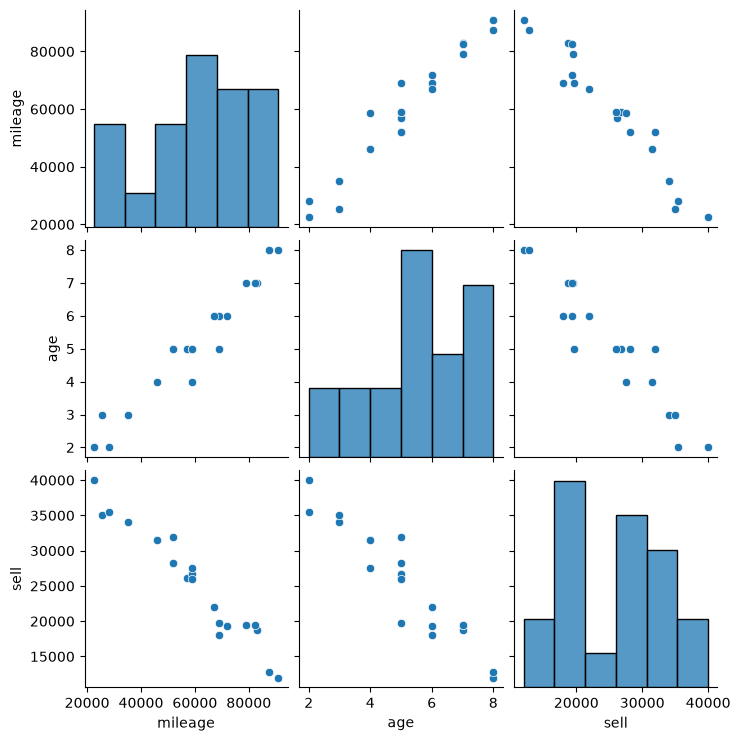

In [10]:
sns.pairplot(data = df)

In [13]:
x = df.iloc[:, :-1]
y = df.iloc[:,-1]

In [14]:
x

,mileage,age
0,69000,6
1,35000,3
2,57000,5
3,22500,2
4,46000,4
5,59000,5
6,52000,5
7,72000,6
8,91000,8
9,67000,6


In [15]:
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     26750
6     32000
7     19300
8     12000
9     22000
10    18700
11    19500
12    26000
13    27500
14    19400
15    35000
16    35500
17    19700
18    12800
19    28200
Name: sell, dtype: int64

In [17]:
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size = 0.2)

In [18]:
print(len(x_train))
print(len(x_test))
print(len(y_train))
print(len(y_test))

16
4
16
4


In [20]:
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.9811001900682248

In [22]:
model.predict([[35000,3]])

c:\Users\PTS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([34248.18142122])

In [24]:
ypred = model.predict(x_test)

In [25]:
ypred

array([25606.10095991, 34248.18142122, 22663.63642543, 14021.55596413])

In [23]:
from sklearn import metrics

In [26]:
metrics.mean_squared_error(y_test,ypred)

1185963.073218892

In [27]:
metrics.r2_score(y_test, ypred)

0.9811001900682248

In [28]:
from math import sqrt
sqrt(metrics.mean_squared_error(y_test, ypred))

1089.0193171927172

In [31]:
metrics.mean_absolute_error(y_test,ypred)

831.8182127149075